Simulations for advancement! 

Part 1) Simulations of Cold Started Horizontal Convection (no hills) with increasing Rayleigh number. 

In [8]:
using Oceananigans

In [3]:
using TopographicHorizontalConvection: HorizontalConvectionSimulation

In [5]:
simulation = HorizontalConvectionSimulation(Ra=1e7, h₀_frac=0.6, numhill = 1, Nx=535, Ny=1, Nz=67, b_init=-0.6, advection=true, architecture=CPU())

Simulation of NonhydrostaticModel{CPU, ImmersedBoundaryGrid}(time = 0 seconds, iteration = 0)
├── Next time step: 12.217 ms
├── Elapsed wall time: 0 seconds
├── Wall time per iteration: NaN days
├── Stop time: 52.705 minutes
├── Stop iteration : Inf
├── Wall time limit: Inf
├── Callbacks: OrderedDict with 6 entries:
│   ├── stop_time_exceeded => Callback of stop_time_exceeded on IterationInterval(1)
│   ├── stop_iteration_exceeded => Callback of stop_iteration_exceeded on IterationInterval(1)
│   ├── wall_time_limit_exceeded => Callback of wall_time_limit_exceeded on IterationInterval(1)
│   ├── nan_checker => Callback of NaNChecker for u on IterationInterval(100)
│   ├── wizard => Callback of TimeStepWizard(cfl=0.5, max_Δt=Inf, min_Δt=0.0) on IterationInterval(50)
│   └── progress => Callback of (::TopographicHorizontalConvection.var"#progress#9") on IterationInterval(10)
├── Output writers: OrderedDict with 6 entries:
│   ├── checkpointer => Checkpointer{TimeInterval, Vector{Symbol}}

In [1]:
using NCDatasets
using CairoMakie
using Printf
using Oceananigans.Fields
using Oceananigans.AbstractOperations: volume
using NaNStatistics

No hills simulations of horizontal convection:: Ra = 1e5 to 1e7. 

Below is an animation of Ra=1e5 -- laminar

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/nohills1e5.mp4" type "video/mp4">
</video>

In [2]:
using TopographicHorizontalConvection:ε_analysis
using TopographicHorizontalConvection:plot_ε_normalized

In [3]:
ds0_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra100000.0_coldstart_buoyancy.nc"));
ds0_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra100000.0_coldstart_oceanostics.nc"));

we want to create a heatmap comparing simulation epsilon to theoretical epsilon at the equilibrium time. let's assume the equilibrium time is the last ten percent of the timeseries. 

In [121]:
ε_theory_0, ε_avg_0, ε_mean_0 = ε_analysis(ds0_o);
t_0 = ds0_o["time"][:];

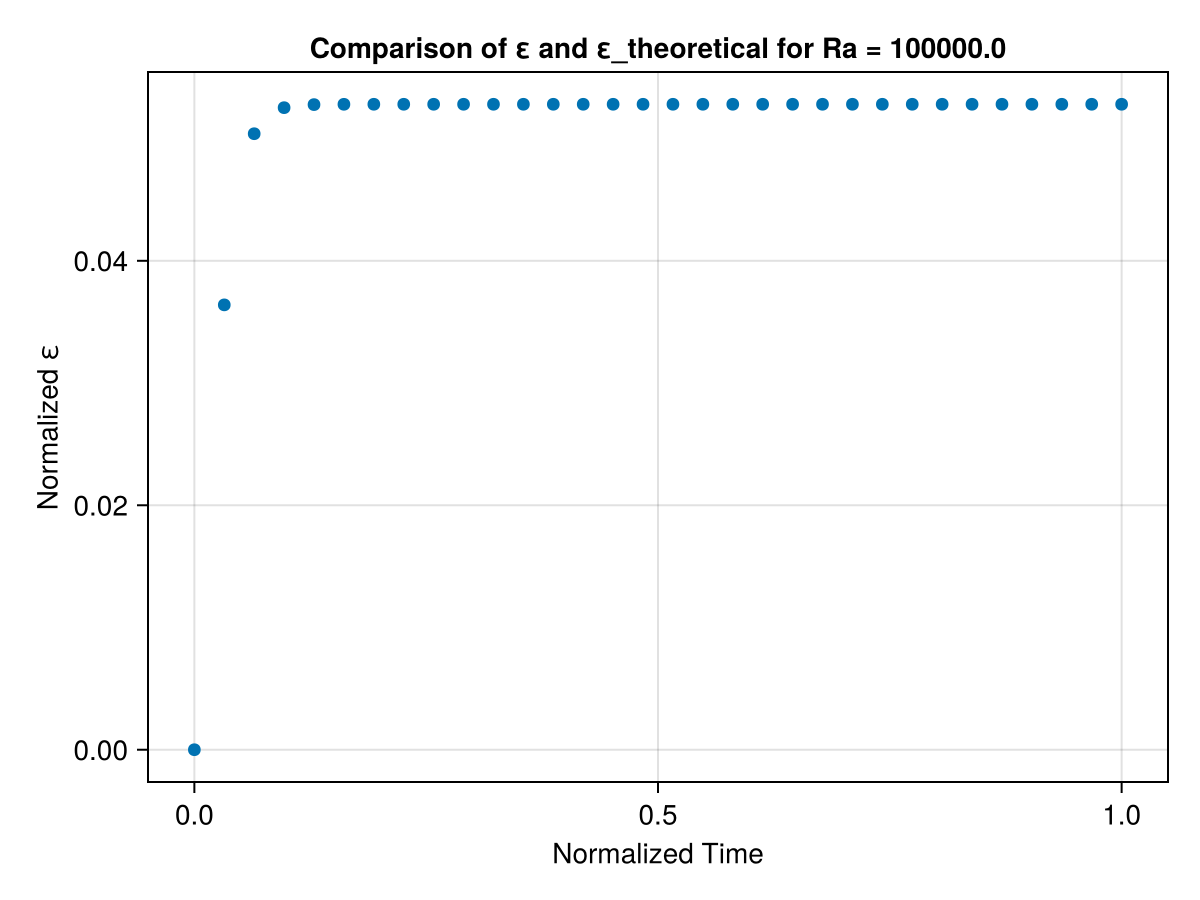

In [5]:
f0 = plot_ε_normalized(ds0_o)

In [60]:
ε_0 = ds0_o["ε"][4+1:end-4, :, 4+1:end-4, :];
time_0 = ds0_o["time"][:];
x = ds0_o["xC"][4+1:end-4];
z = ds0_o["zC"][4+1:end-4];

function plot_ε_equilibrium(ds)
    ε = ds["ε"][4+1:end-4, :, 4+1:end-4, :]
    Ra = ds.attrib["Ra"]
    time = ds["time"][:]
    x = ds["xC"][4+1:end-4]
    z = ds["zC"][4+1:end-4]
    equilibrium_start = round(Int, 0.7 * size(time, 1))
    time_eq_start = time[equilibrium_start]
    ε_eq = ε[:, 1, :, equilibrium_start]

    ε_theory = ε_analysis(ds)[1]

    fig = Figure()
    ax = Axis(fig[1, 1], aspect =8, xlabel="x", ylabel="z", title="Mechanical Energy Dissipation Rate Normalized of Ra = $Ra Simulation at Equilibrium Time")

    hm = heatmap!(ax, x, z, ε_eq, colormap=:viridis)
    Colorbar(fig[1, 2], hm)
    return fig
end


plot_ε_equilibrium (generic function with 1 method)

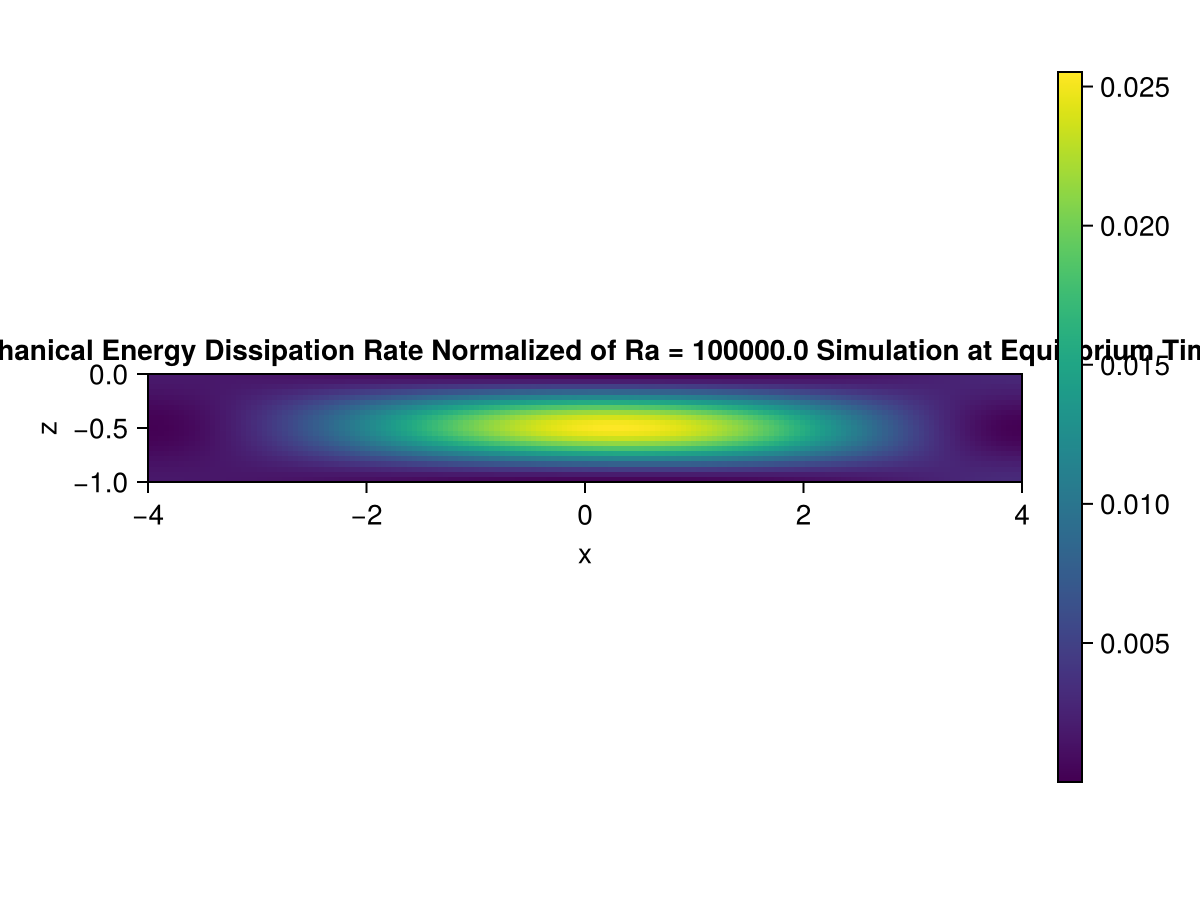

In [61]:
fig = plot_ε_equilibrium(ds0_o)

Next is the Ra=1e6 no hills simulation

In [4]:
ds1_b = NCDataset(string("/Users/hfdrake/code/output/turbulent_h0_Ra1.0e6_coldstart_buoyancy.nc"));
ds1_o = NCDataset(string("/Users/hfdrake/code/output/turbulent_h0_Ra1.0e6_coldstart_oceanostics.nc"));

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/nohills1e6.mp4" type "video/mp4">
</video>

In [7]:
Ra = ds1_o.attrib["Ra"]
Pr = ds1_b.attrib["Pr"]
H = ds1_b.attrib["H"]
b★ = ds1_b.attrib["b★"]
κ = ds1_b.attrib["κ"]
ν = ds1_b.attrib["ν"]
Lx = ds1_b.attrib["Lx"]

8.0

In [8]:
ε_theory_1, ε_avg_1, ε_mean_1 = ε_analysis(ds1_o);

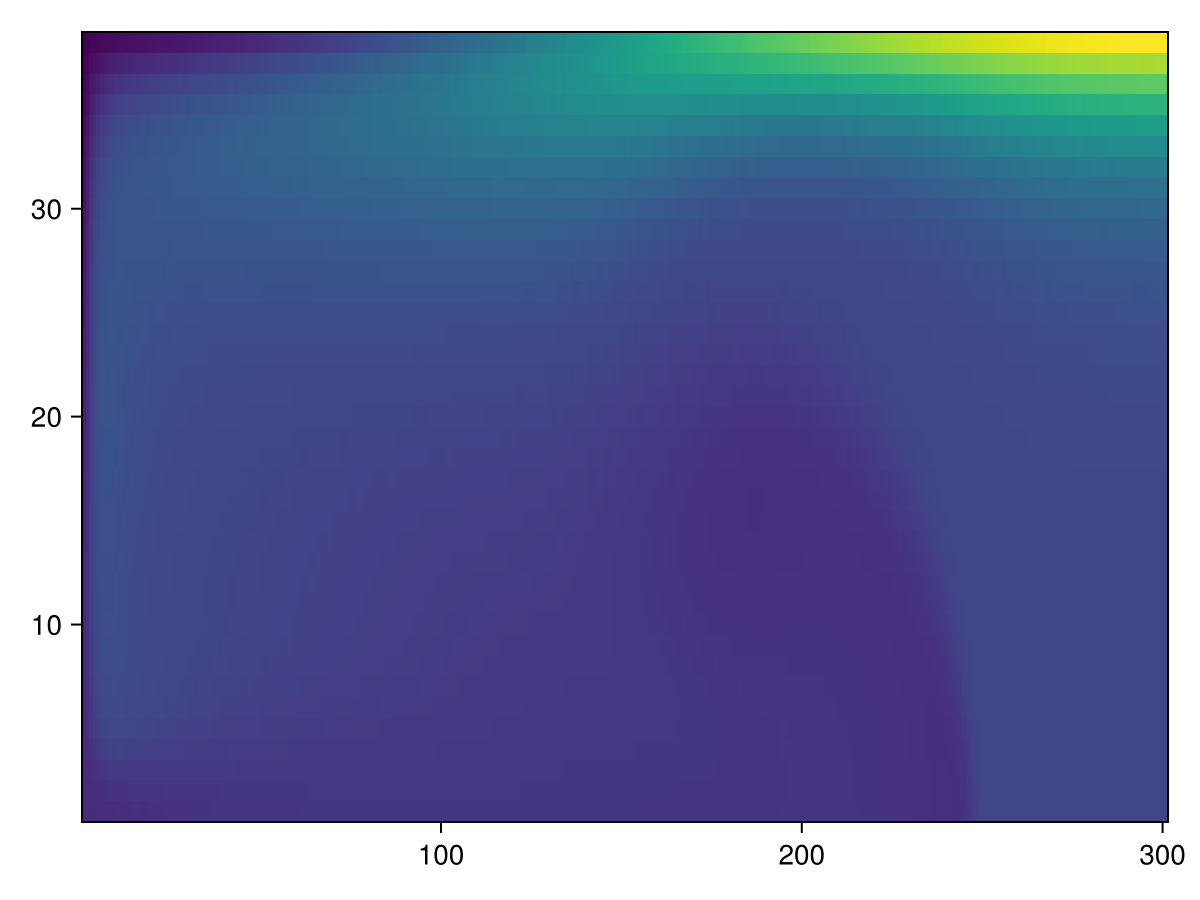

In [9]:
b = ds1_b["b"][4+1:end-4, :, 4+1:end-4, :];
time = ds1_b["time"][:];
size(time)

heatmap(b[:, 1, :, 10])

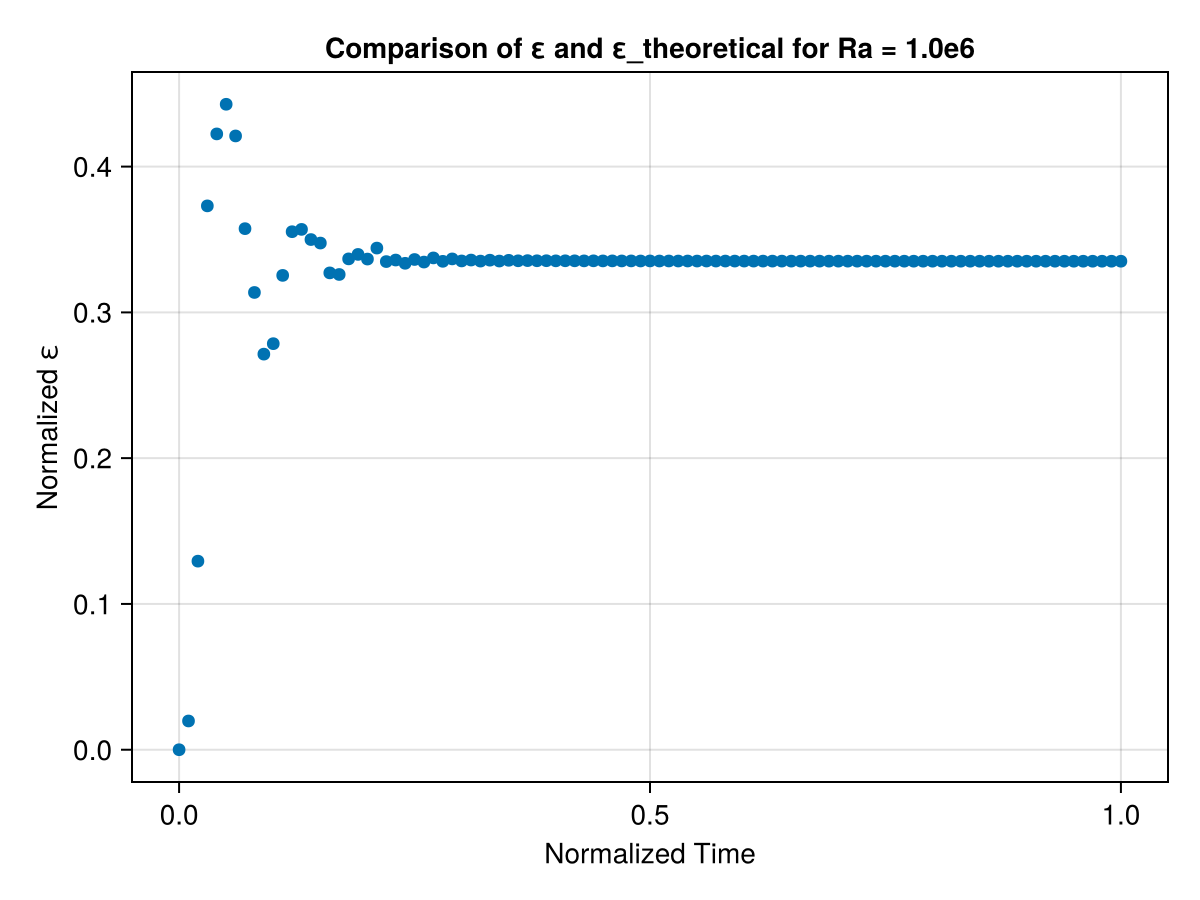

In [10]:
f1 = plot_ε_normalized(ds1_o)

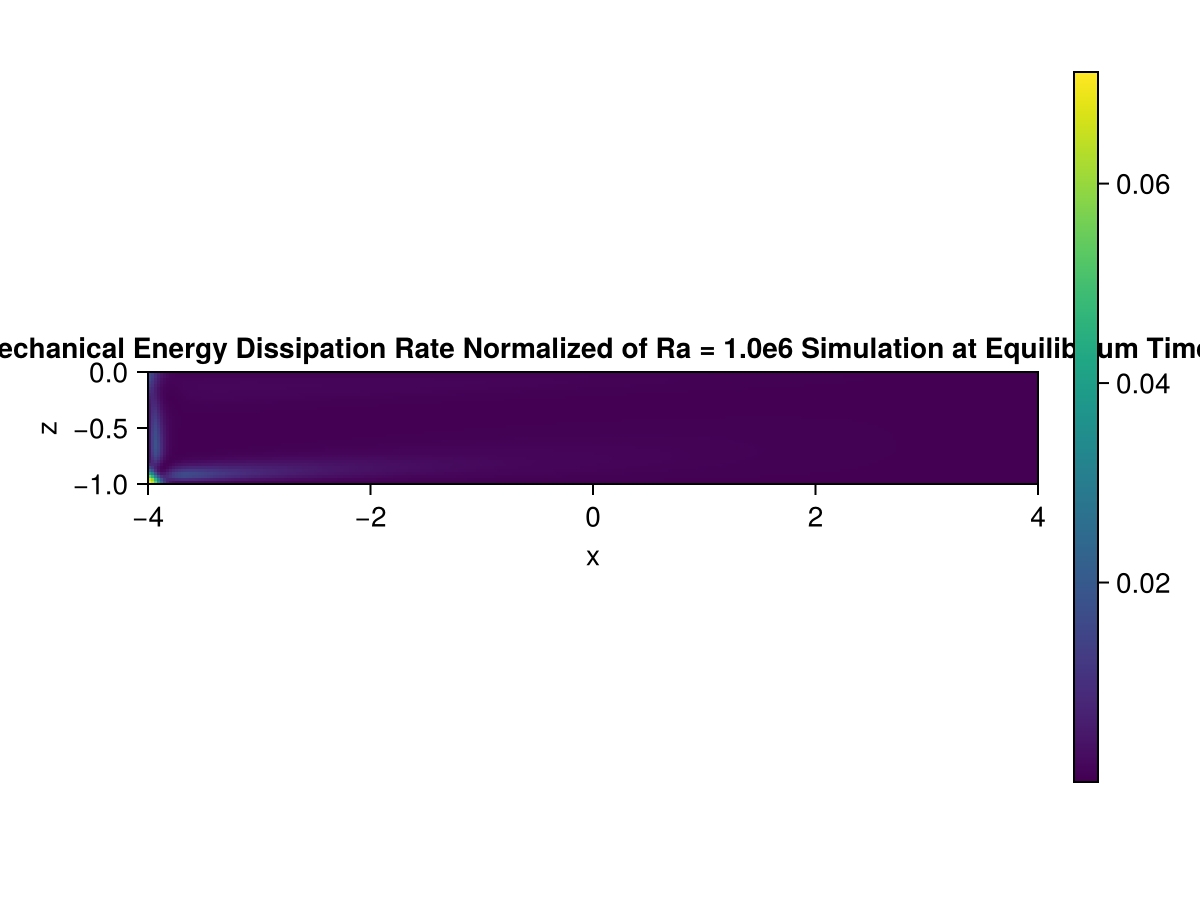

In [62]:
#repeat the equilibrium epsilon plot

fig2 = plot_ε_equilibrium(ds1_o)

In the second simulation we increase the Rayleigh number to 1e7
I didn't run this all the way to equilibrium $\tau_{eq} = \sqrt{1\times 10^{8}}$ because it took over 12 hours to just run up to $t=1830$ locally. 

In [5]:
ds2_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra1.0e7_coldstart_oceanostics.nc"));
ds2_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra1.0e7_coldstart_buoyancy.nc"));

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/nohills1e7.mp4" type "video/mp4">
</video>

In [12]:
ε_theory_2, ε_avg_2, ε_mean_2 = ε_analysis(ds2_o);

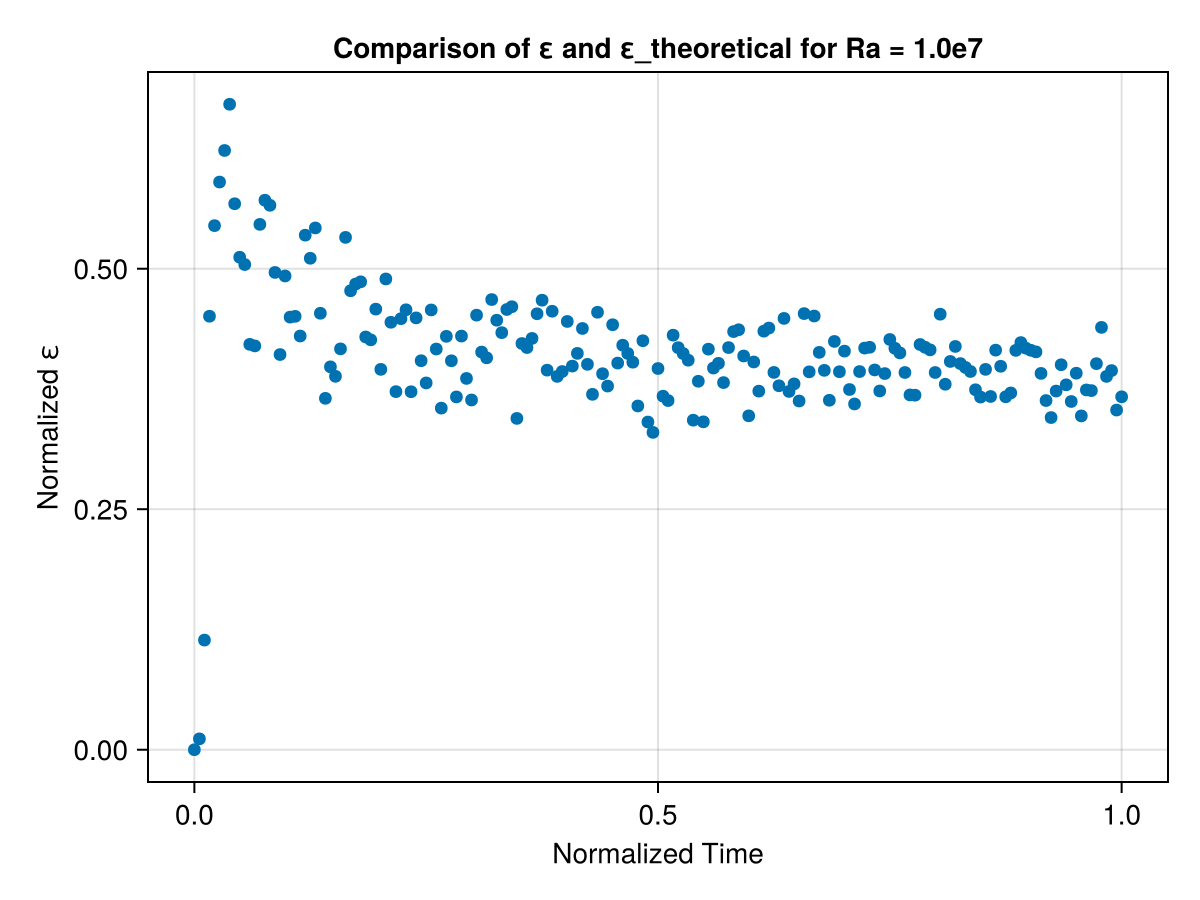

In [13]:
f2 = plot_ε_normalized(ds2_o)

In [97]:
nanmean(ε_eq)

0.0002639896319225713

In [94]:
#equilibrium ε plot

ε = ds["ε"][4+1:end-4, 1, 4+1:end-4, :]
Ra = ds.attrib["Ra"]
time = ds["time"][:]
print(size(time))
x = ds["xC"][4+1:end-4]
z = ds["zC"][4+1:end-4]
equilibrium_start = round(Int, 0.9 * size(time, 1))
print(equilibrium_start)
time_eq_start = time[equilibrium_start]
ε_eq = ε[:, :, equilibrium_start]

ε_theory = ε_analysis(ds)[1]



#fig3 = plot_ε_equilibrium(ds2_o)

(185,)166

0.0006324555320336759

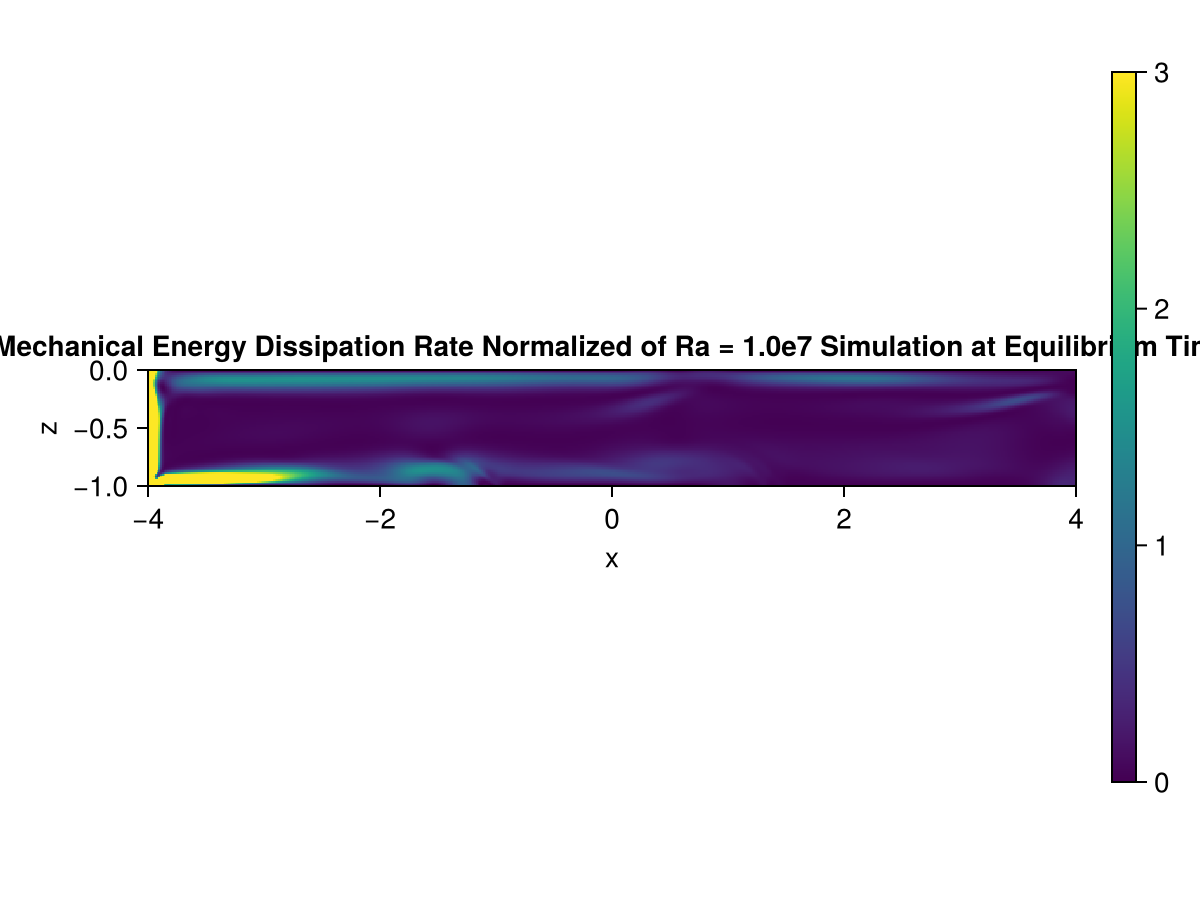

In [101]:
##
fig = Figure()
ax = Axis(fig[1, 1], aspect =8, xlabel="x", ylabel="z", title="Mechanical Energy Dissipation Rate Normalized of Ra = $Ra Simulation at Equilibrium Time")
hm = heatmap!(ax, x, z, ε_eq./ε_theory, colorrange = (0,3),colormap=:viridis)
Colorbar(fig[1, 2], hm)
fig

Below is the animation and similar analysis plot for Ra=5e6

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/nohills5e6.mp4" type "video/mp4">
</video>

In [6]:
ds3_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra5.0e6_coldstart_buoyancy.nc"));
ds3_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra5.0e6_coldstart_oceanostics.nc"));

In [15]:
ε_theory_3, ε_avg_3, ε_mean_3 = ε_analysis(ds3_o);

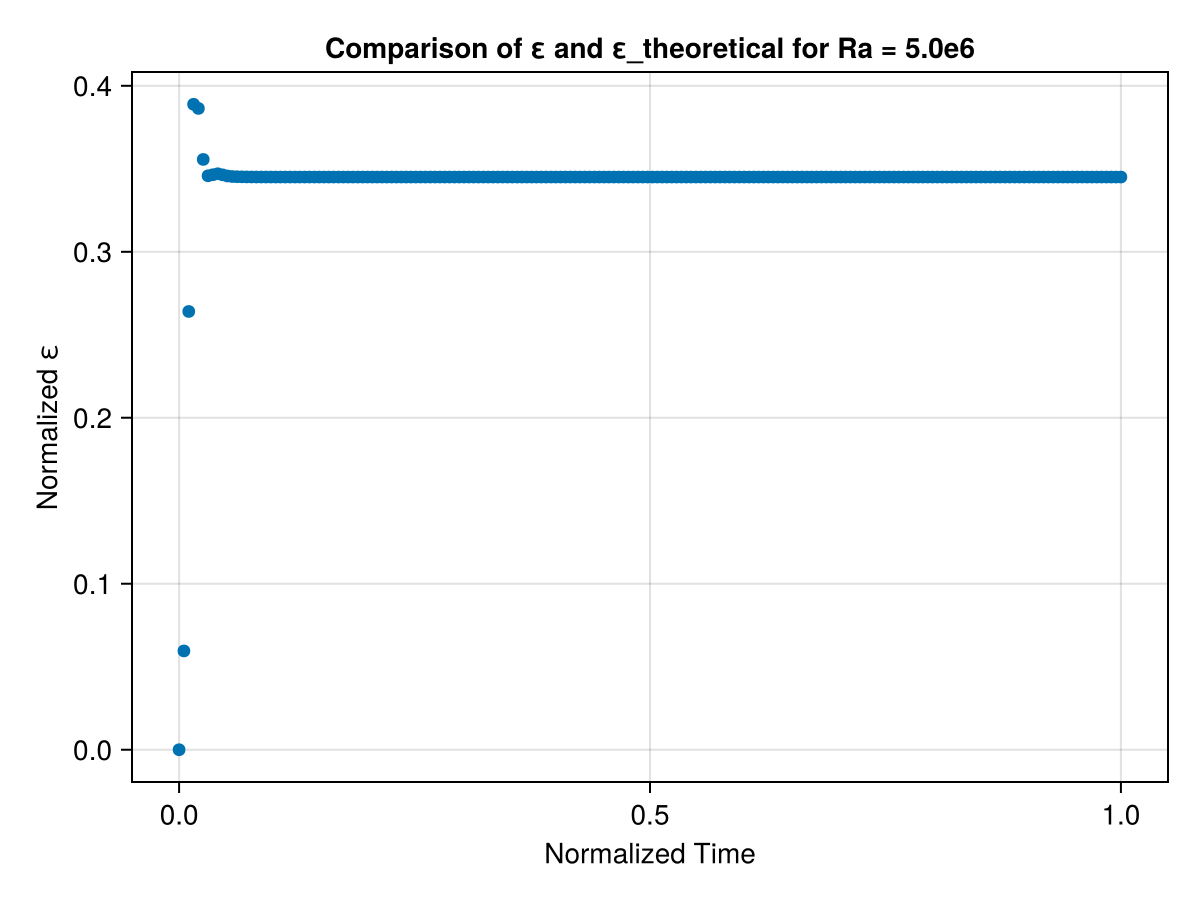

In [16]:
f3 = plot_ε_normalized(ds3_o)

f3

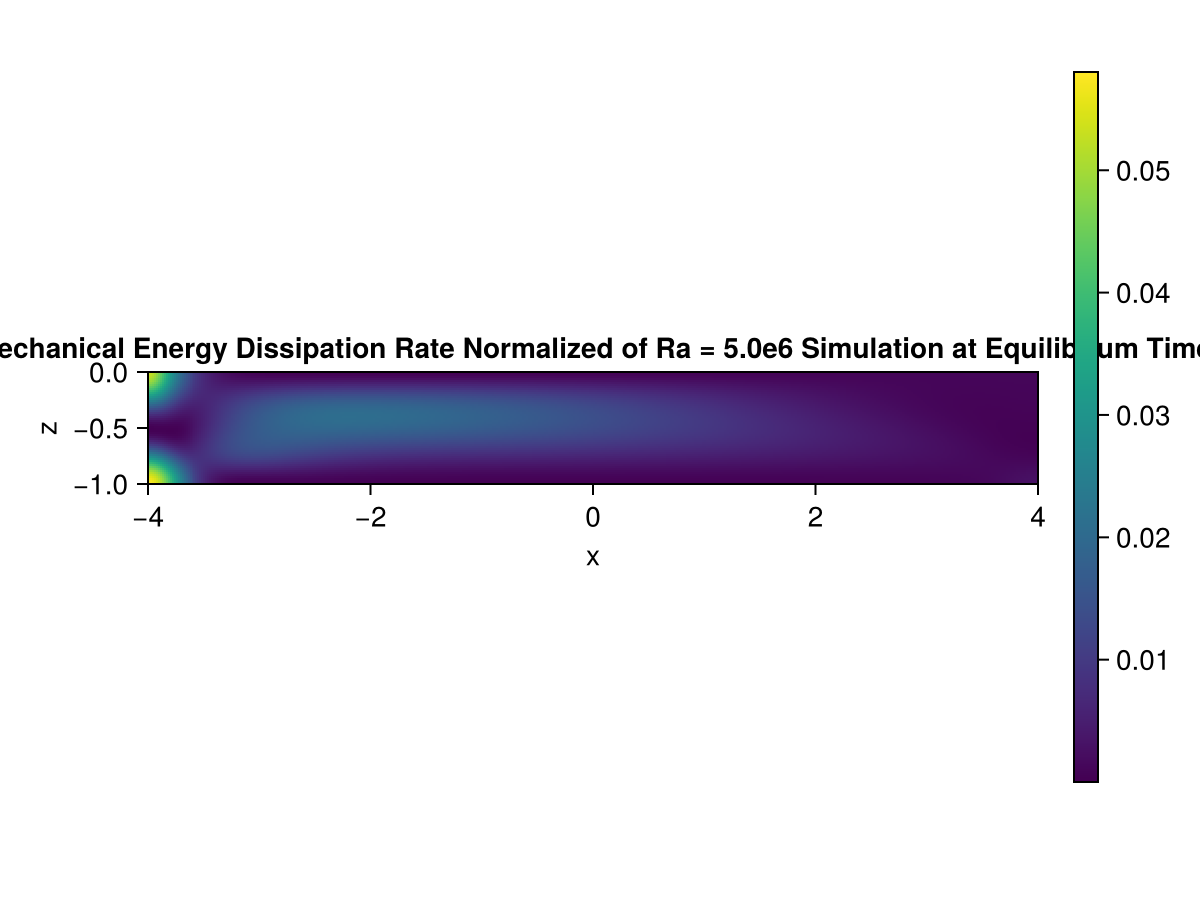

In [64]:
#equilibrium ε plot

fig4 = plot_ε_equilibrium(ds3_o)

NOW for the hills simulations

we start with Ra=1e5

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/onehill1e5.mp4" type "video/mp4">
</video>

In [13]:
ds_h0_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_buoyancy.nc"));
ds_h0_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_oceanostics.nc"));

below is Ra=1e6 with one hill

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/onehill1e6.mp4" type "video/mp4">
</video>

In [14]:
ds_h1_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_buoyancy.nc"));
ds_h1_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_oceanostics.nc"));

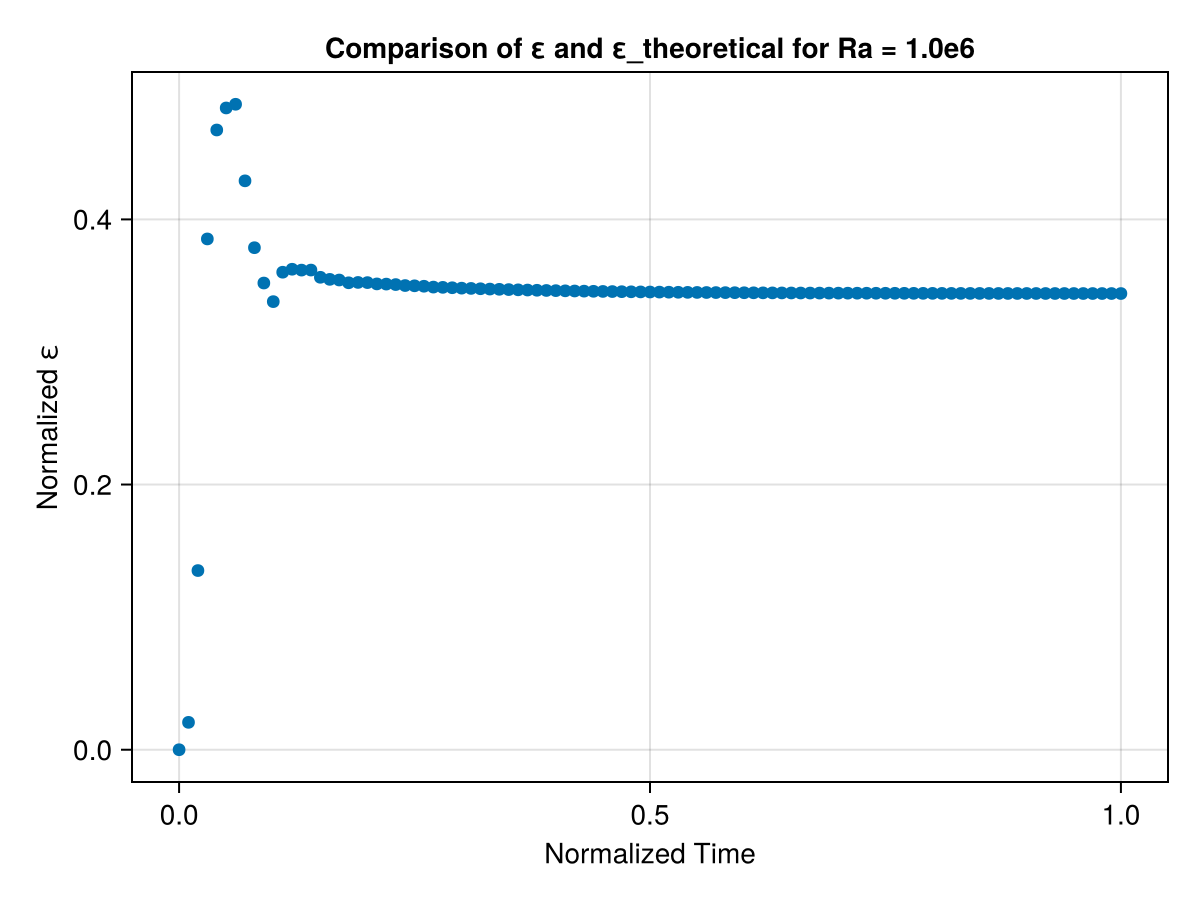

In [18]:
ε_theory_h1, ε_avg_h1, ε_mean_h1 = ε_analysis(ds_h1_o);
f_h1 = plot_ε_normalized(ds_h1_o)

f_h1

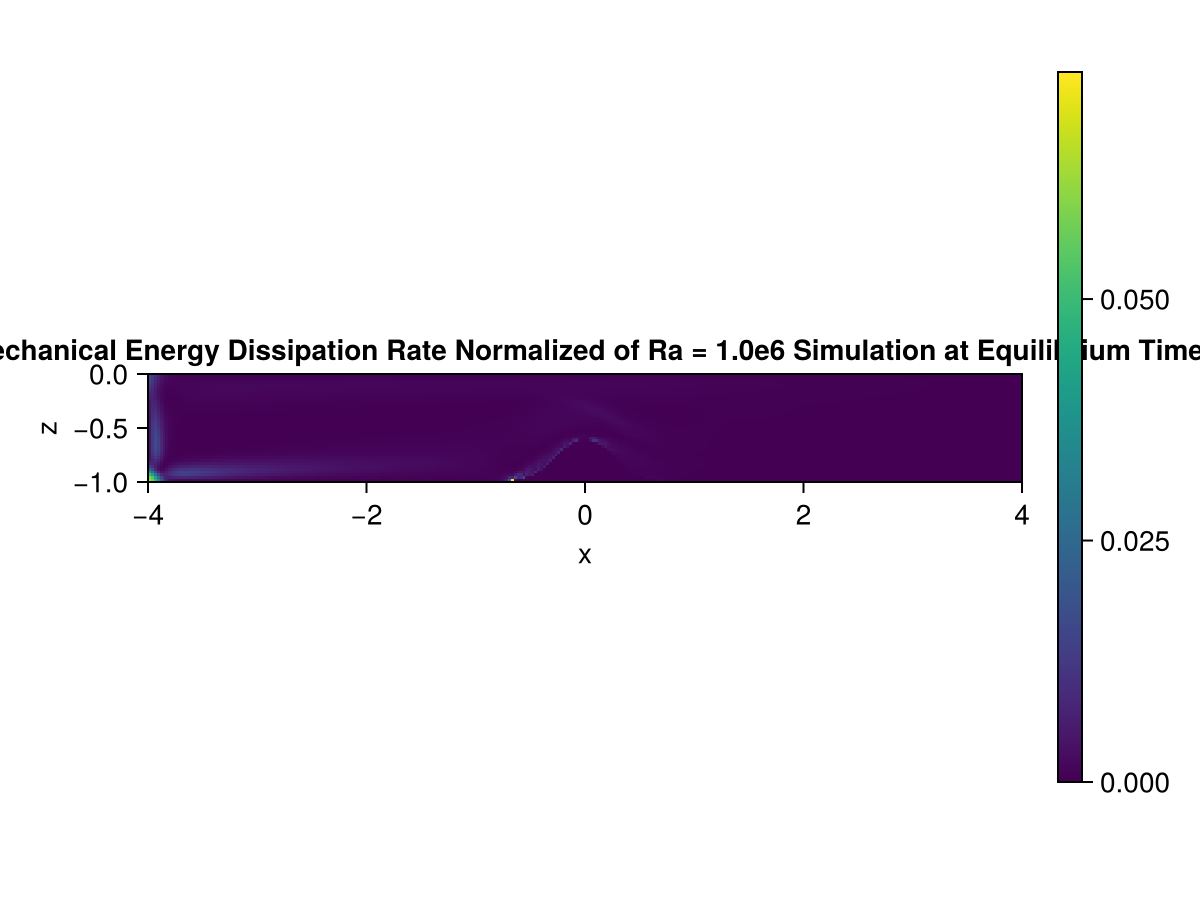

In [65]:
fig5 = plot_ε_equilibrium(ds_h1_o)

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/onehill5e6.mp4" type "video/mp4">
</video>

In [15]:
#Ra 5e6 one hill 

ds_h2_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_buoyancy.nc"));
ds_h2_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_oceanostics.nc"));


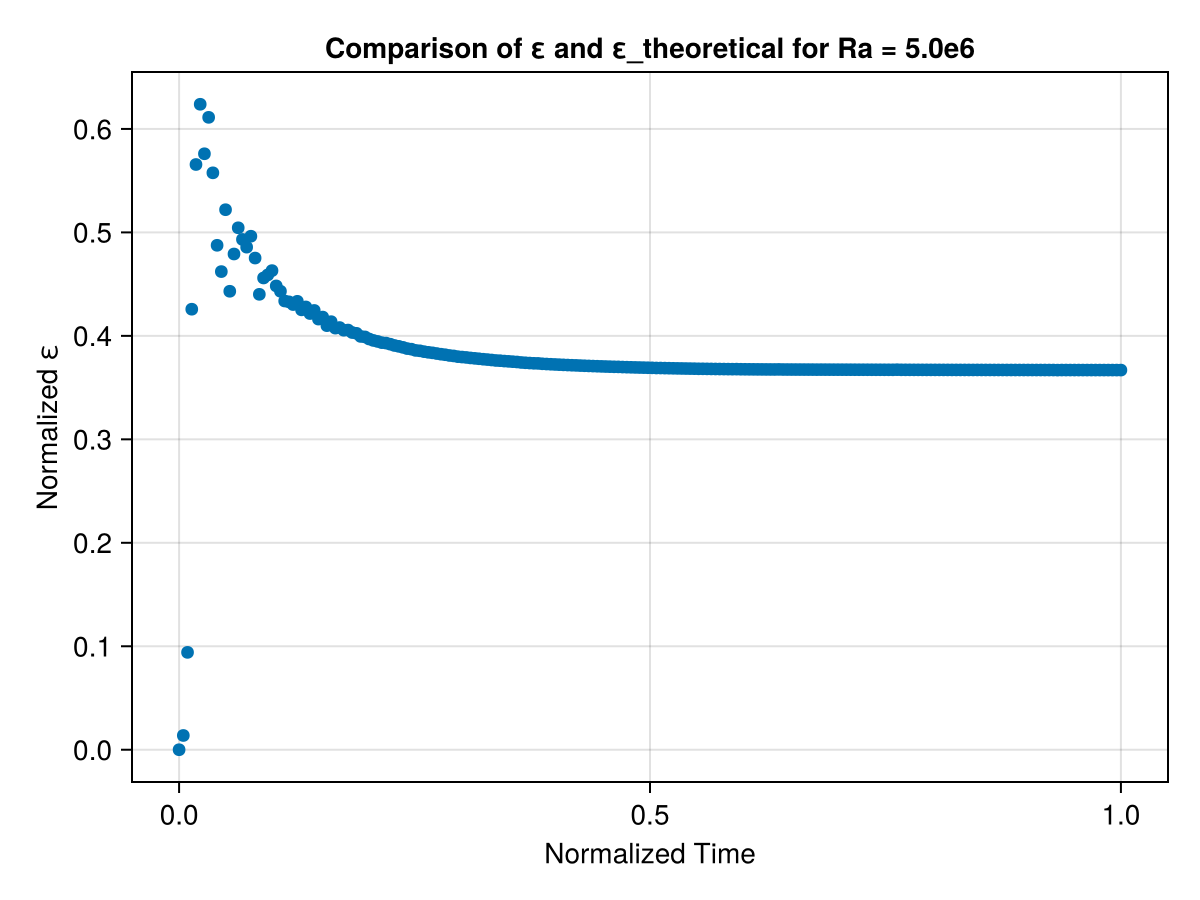

In [ ]:
ε_theory_h2, ε_avg_h2, ε_mean_h2 = ε_analysis(ds_h2_o);
f_h2 = plot_ε_normalized(ds_h2_o);

Rayleigh number 1e7 with one hill

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/onehill1e7.mp4" type "video/mp4">
</video>

In [16]:
#Ra 1e7 one hill

ds_h3_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_buoyancy.nc"));
ds_h3_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_oceanostics.nc"));

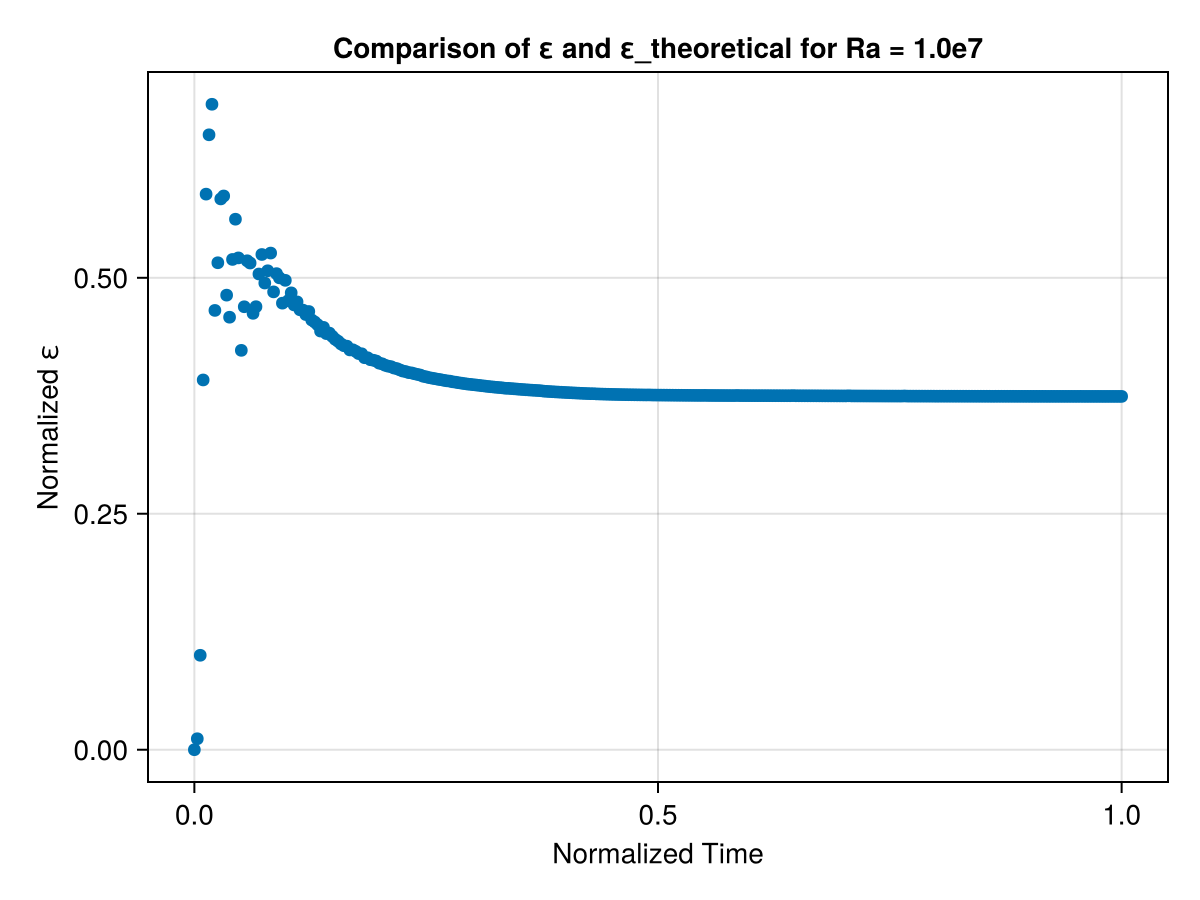

In [110]:
ε_theory_h3, ε_avg_h3, ε_mean_h3 = ε_analysis(ds_h3_o);
f_h3 = plot_ε_normalized(ds_h3_o)

In [107]:
b = ds_h3_b["b"][4+1:end-4, :, 4+1:end-4, :];
time = ds_h3_b["time"][:];

okay, time to make a joint plot of normalized epsilon vs time for all RA

lets start with no hills

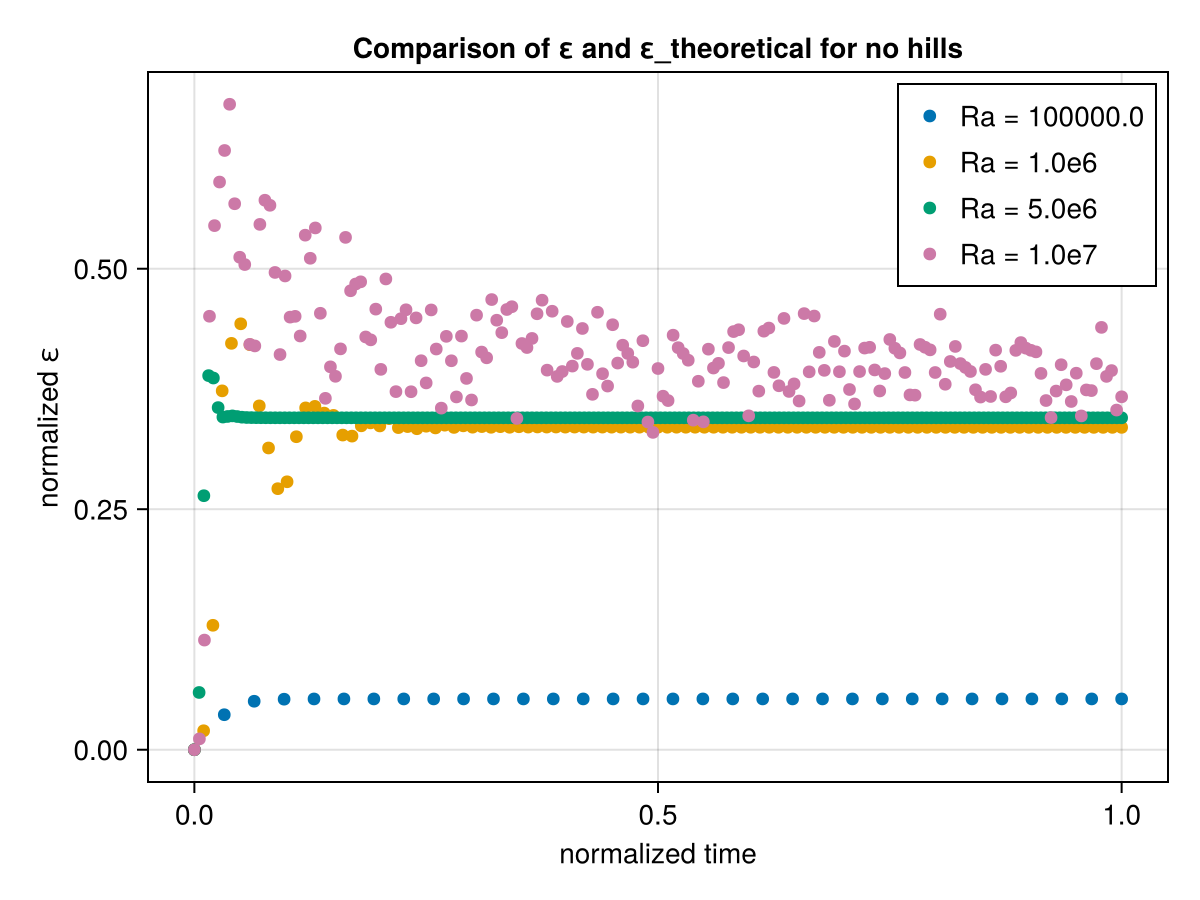

In [11]:
list_of_datasets = [ds0_o, ds1_o, ds3_o, ds2_o]

f = Figure()
ax = Axis(f[1, 1], xlabel="normalized time", ylabel="normalized ε", title="Comparison of ε and ε_theoretical for no hills")
for ds in list_of_datasets
    plot_ε_normalized(ax, ds)
end

axislegend(ax)
f

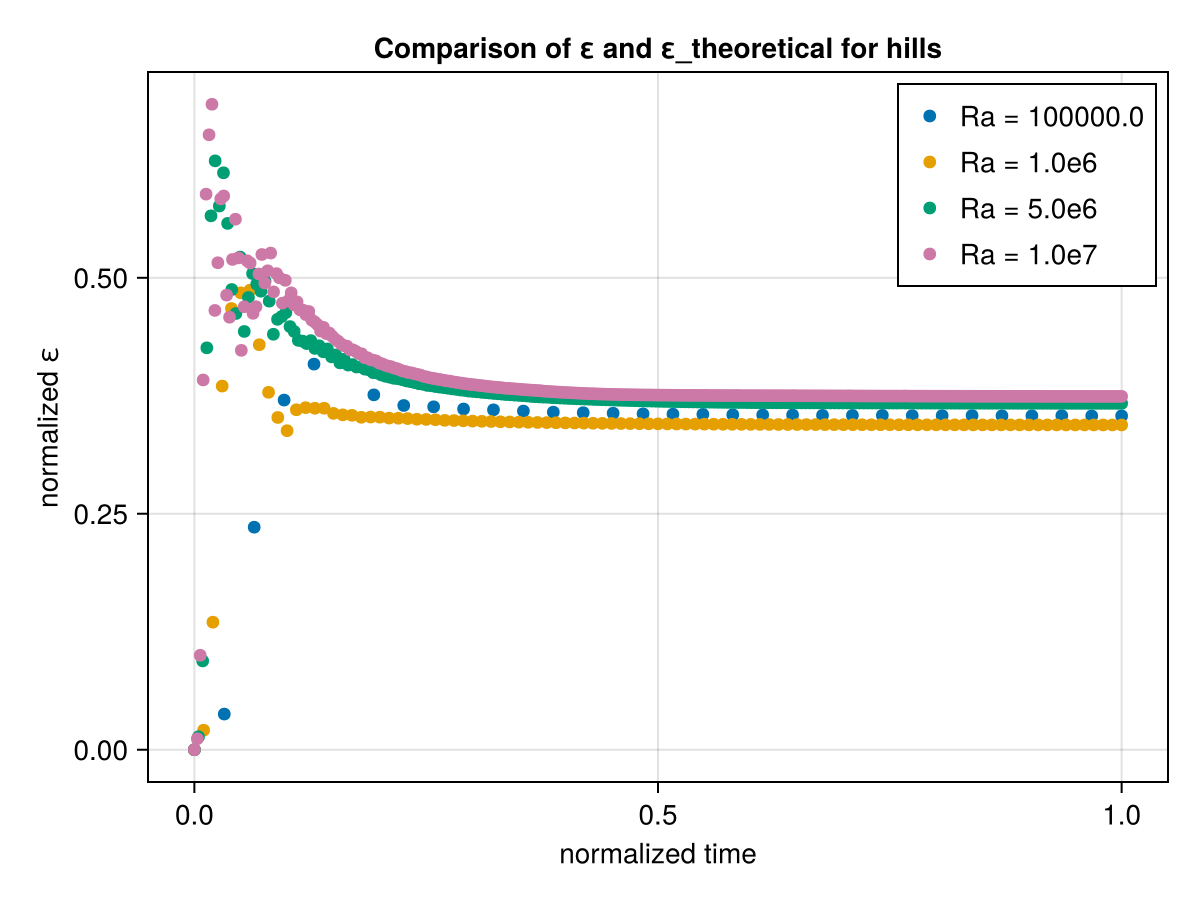

In [17]:
list_hill_datasets = [ds_h0_o,ds_h1_o, ds_h2_o, ds_h3_o]
f_hills = Figure()
ax_hills = Axis(f_hills[1, 1], xlabel="normalized time", ylabel="normalized ε", title="Comparison of ε and ε_theoretical for hills")
for ds in list_hill_datasets
    plot_ε_normalized(ax_hills, ds)
end

axislegend(ax_hills)
f_hills